In [6]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
dataset = load_dataset('surrey-nlp/BESSTIE-CW-26')

train_df = pd.DataFrame(dataset['train'])
val_df   = pd.DataFrame(dataset['validation'])
test_df  = pd.DataFrame(dataset['test'])

print("Train size: ", len(train_df))
print("Val size: ", len(val_df))
print("Test size: ", len(test_df))
print(train_df.head(3))

c:\Users\Aiyoun Khan Anady\miniconda3\envs\python_tests\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Aiyoun Khan Anady\.cache\huggingface\hub\datasets--surrey-nlp--BESSTIE-CW-26. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Generating test split: 100%|██████████| 2183/2183 [00:00<00:00, 207279.69 

Train size:  3747
Val size:  313
Test size:  2183
                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  


In [8]:
# Turning the floats into int 

train_df['Sentiment'] = train_df['Sentiment'].astype(int)
train_df['Sarcasm'] = train_df['Sarcasm'].astype(int)

val_df['Sentiment'] = val_df['Sentiment'].astype(int)
val_df['Sarcasm']   = val_df['Sarcasm'].astype(int)

test_df['Sentiment'] = test_df['Sentiment'].astype(int)
test_df['Sarcasm']   = test_df['Sarcasm'].astype(int)

print(train_df.dtypes)
print(train_df.head(3))

text         object
variety      object
source       object
Sentiment     int64
Sarcasm       int64
dtype: object
                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   

   Sentiment  Sarcasm  
0          0        0  
1          0        1  
2          1        0  


In [11]:
# Training data per variety

train_uk = train_df[train_df['variety'] == 'en-UK']
train_au = train_df[train_df['variety'] == 'en-AU']
train_in = train_df[train_df['variety'] == 'en-IN']

# Test data per variety

test_uk = test_df[test_df['variety'] == 'en-UK']
test_au = test_df[test_df['variety'] == 'en-AU']
test_in = test_df[test_df['variety'] == 'en-IN']

print("Train sizes:")
print("en-UK: ", len(train_uk))
print("en-AU: ", len(train_au))
print("en-IN: ", len(train_in))

print("\nTest sizes:")
print("en-UK: ", len(test_uk))
print("en-AU: ", len(test_au))
print("en-IN: ", len(test_in))

Train sizes:
en-UK:  1203
en-AU:  1145
en-IN:  1399

Test sizes:
en-UK:  700
en-AU:  667
en-IN:  816


In [40]:
# All varieties combined - for Q2.1

X_train = train_df['text'].tolist()
X_val = val_df['text'].tolist()
X_test = test_df['text'].tolist()

# Sarcasm labels

y_train_sarcasm = train_df['Sarcasm'].tolist()
y_val_sarcasm = val_df['Sarcasm'].tolist()
y_test_sarcasm = test_df['Sarcasm'].tolist()

# Sentiment labels

y_train_sentiment = train_df['Sentiment'].tolist()
y_val_sentiment   = val_df['Sentiment'].tolist()
y_test_sentiment  = test_df['Sentiment'].tolist()

print("Sarcasm class distribution in training set:")
print("Not Sarcastic (0): ", y_train_sarcasm.count(0))
print("Sarcastic (1): ", y_train_sarcasm.count(1))

print("\nSentiment class distribution in training set:")
print("Negative (0): ", y_train_sentiment.count(0))
print("Positive (1): ", y_train_sentiment.count(1))

Sarcasm class distribution in training set:
Not Sarcastic (0):  3223
Sarcastic (1):  524

Sentiment class distribution in training set:
Negative (0):  1907
Positive (1):  1840


In [25]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2)) # Taken single and double words as features

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF matrix shape:")
print("Train: ", X_train_tfidf.shape)
print("Val: ", X_val_tfidf.shape)
print("Test: ", X_test_tfidf.shape)

TF-IDF matrix shape:
Train:  (3747, 10000)
Val:  (313, 10000)
Test:  (2183, 10000)


In [29]:
# Logistic regression on Sarcasm

lr_sarcasm = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_sarcasm.fit(X_train_tfidf, y_train_sarcasm)

lr_sarcasm_preds = lr_sarcasm.predict(X_test_tfidf)

print(f"{'-'*10} Logistic Regression - Sarcasm {'-'*10}")
print(classification_report(y_test_sarcasm, lr_sarcasm_preds, target_names=['Not Sarcastic', 'Sarcastic']))

---------- Logistic Regression - Sarcasm ----------
               precision    recall  f1-score   support

Not Sarcastic       0.92      0.79      0.85      1878
    Sarcastic       0.31      0.59      0.41       305

     accuracy                           0.76      2183
    macro avg       0.62      0.69      0.63      2183
 weighted avg       0.84      0.76      0.79      2183



In [33]:
# Logistic Regression on Sentiment

lr_sentiment = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_sentiment.fit(X_train_tfidf, y_train_sentiment)

lr_sentiment_preds = lr_sentiment.predict(X_test_tfidf)

print(f"{'-'*10} Logistic Regression - Sentiment {'-'*10}")
print(classification_report(y_test_sentiment, lr_sentiment_preds, target_names=['Negative', 'Positive']))

---------- Logistic Regression - Sentiment ----------
              precision    recall  f1-score   support

    Negative       0.82      0.86      0.84      1117
    Positive       0.84      0.80      0.82      1066

    accuracy                           0.83      2183
   macro avg       0.83      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183



In [34]:
# SVM on Sarcasm

svm_sarcasm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_sarcasm.fit(X_train_tfidf, y_train_sarcasm)

svm_sarcasm_preds = svm_sarcasm.predict(X_test_tfidf)

print(f"{'-'*10} SVM - Sarcasm {'-'*10}")
print(classification_report(y_test_sarcasm, svm_sarcasm_preds, target_names=['Not Sarcastic', 'Sarcastic']))

---------- SVM - Sarcasm ----------
               precision    recall  f1-score   support

Not Sarcastic       0.89      0.89      0.89      1878
    Sarcastic       0.31      0.32      0.31       305

     accuracy                           0.81      2183
    macro avg       0.60      0.60      0.60      2183
 weighted avg       0.81      0.81      0.81      2183



In [35]:
svm_sentiment = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_sentiment.fit(X_train_tfidf, y_train_sentiment)

svm_sentiment_preds = svm_sentiment.predict(X_test_tfidf)

print(f"{'-'*10} SVM - Sentiment {'-'*10}")
print(classification_report(y_test_sentiment, svm_sentiment_preds, target_names=['Negative', 'Positive']))

---------- SVM - Sentiment ----------
              precision    recall  f1-score   support

    Negative       0.83      0.85      0.84      1117
    Positive       0.84      0.81      0.83      1066

    accuracy                           0.83      2183
   macro avg       0.83      0.83      0.83      2183
weighted avg       0.83      0.83      0.83      2183



In [36]:
# Run 2 - different random seed
lr_sarcasm_run2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=0)
lr_sarcasm_run2.fit(X_train_tfidf, y_train_sarcasm)
lr_sarcasm_preds_run2 = lr_sarcasm_run2.predict(X_test_tfidf)

svm_sarcasm_run2 = LinearSVC(class_weight='balanced', random_state=0, max_iter=2000)
svm_sarcasm_run2.fit(X_train_tfidf, y_train_sarcasm)
svm_sarcasm_preds_run2 = svm_sarcasm_run2.predict(X_test_tfidf)

from sklearn.metrics import f1_score

lr_f1_run1  = f1_score(y_test_sarcasm, lr_sarcasm_preds, average='macro')
lr_f1_run2  = f1_score(y_test_sarcasm, lr_sarcasm_preds_run2, average='macro')
svm_f1_run1 = f1_score(y_test_sarcasm, svm_sarcasm_preds, average='macro')
svm_f1_run2 = f1_score(y_test_sarcasm, svm_sarcasm_preds_run2, average='macro')

print(f"{'-'*10} Sarcasm - 2 Run Comparison {'-'*10}")
print(f"LR  - Run 1: {lr_f1_run1:.4f} | Run 2: {lr_f1_run2:.4f}")
print(f"SVM - Run 1: {svm_f1_run1:.4f} | Run 2: {svm_f1_run2:.4f}")

---------- Sarcasm - 2 Run Comparison ----------
LR  - Run 1: 0.6277 | Run 2: 0.6277
SVM - Run 1: 0.6012 | Run 2: 0.6012


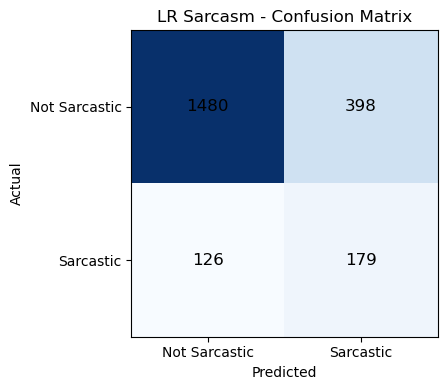

[[1480  398]
 [ 126  179]]


In [37]:
cm = confusion_matrix(y_test_sarcasm, lr_sarcasm_preds)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Sarcastic', 'Sarcastic'])
ax.set_yticklabels(['Not Sarcastic', 'Sarcastic'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12)

ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('LR Sarcasm - Confusion Matrix')
plt.tight_layout()
plt.savefig('lr_sarcasm_cm.png', dpi=150)
plt.show()
print(cm)

In [39]:
from sklearn.metrics import f1_score, precision_score, recall_score

models = {
    'LR - Sarcasm'   : (y_test_sarcasm,   lr_sarcasm_preds),
    'SVM - Sarcasm'  : (y_test_sarcasm,   svm_sarcasm_preds),
    'LR - Sentiment' : (y_test_sentiment, lr_sentiment_preds),
    'SVM - Sentiment': (y_test_sentiment, svm_sentiment_preds),
}

for name, (y_true, y_pred) in models.items():
    p  = precision_score(y_true, y_pred, average='macro')
    r  = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    print(name)
    print("  Precision: ", round(p, 4))
    print("  Recall: ", round(r, 4))
    print("  Macro F1: ", round(f1, 4))
    print()

LR - Sarcasm
  Precision:  0.6159
  Recall:  0.6875
  Macro F1:  0.6277

SVM - Sarcasm
  Precision:  0.6004
  Recall:  0.602
  Macro F1:  0.6012

LR - Sentiment
  Precision:  0.8305
  Recall:  0.8289
  Macro F1:  0.8292

SVM - Sentiment
  Precision:  0.8327
  Recall:  0.8319
  Macro F1:  0.8321

